In [1]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy import stats
import numpy as np

In [2]:
adata = sc.read_h5ad("/rds/general/user/ao225/home/CardiaFinal/Data/Post_Processed/Science/NewCardiac.h5ad")

In [ ]:
auc_df = pd.DataFrame(adata.obsm["AUCell"], columns=adata.uns["regulons"], index=adata.obs_names)
pb = auc_df.groupby([adata.obs["donor_id"].values, adata.obs["disease"].values],
                    observed=True).mean()
pb.index.names = ["donor", "disease"]
print(pb.shape)                                              
print(pb.index.get_level_values("disease").value_counts())  # 42 DCM, 12 normal

from scipy import stats

dcm = pb.xs("dilated cardiomyopathy", level="disease")
nor = pb.xs("normal", level="disease")

t, p = stats.ttest_ind(dcm, nor, axis=0, equal_var=False)
out = pd.DataFrame({
    "regulon": pb.columns,
    "mean_DCM": dcm.mean(0).values,
    "mean_normal": nor.mean(0).values,
    "logFC": (dcm.mean(0) - nor.mean(0)).values,
    "t": t, "pval": p,
})
out["padj"] = stats.false_discovery_control(out["pval"])
out = out.sort_values("padj")
print(out.head(20).to_string(index=False))

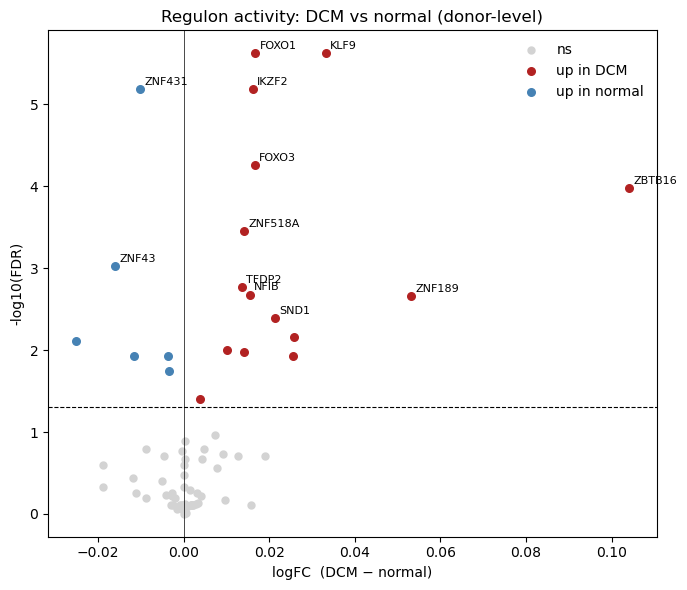

In [5]:
out["neglog10_padj"] = -np.log10(out["padj"])
sig = out["padj"] < 0.05

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(out.loc[~sig, "logFC"], out.loc[~sig, "neglog10_padj"],
           c="lightgray", s=25, label="ns")
ax.scatter(out.loc[sig & (out.logFC > 0), "logFC"], out.loc[sig & (out.logFC > 0), "neglog10_padj"],
           c="firebrick", s=30, label="up in DCM")
ax.scatter(out.loc[sig & (out.logFC < 0), "logFC"], out.loc[sig & (out.logFC < 0), "neglog10_padj"],
           c="steelblue", s=30, label="up in normal")

# label the strongest movers (by effect size, among significant)
top = out[sig].head(12)   # already sorted by padj
for _, r in top.iterrows():
    ax.annotate(r["regulon"], (r["logFC"], r["neglog10_padj"]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), ls="--", c="k", lw=0.8)
ax.axvline(0, ls="-", c="k", lw=0.5)
ax.set_xlabel("logFC  (DCM − normal)")
ax.set_ylabel("-log10(FDR)")
ax.set_title("Regulon activity: DCM vs normal (donor-level)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("volcano_regulons_DCM_vs_normal.png", dpi=200)
plt.show()

In [12]:
import pandas as pd, numpy as np
from ast import literal_eval
from collections import defaultdict
from scipy.stats import fisher_exact, false_discovery_control

# 1. regulon -> target symbols (pySCENIC motifs)
mot = pd.read_csv("/rds/general/user/ao225/home/CardiaFinal/Results/SCENIC/SCENIC_results/lv_regulons.motifs.csv",
                  header=[0,1], index_col=[0,1], skipinitialspace=True)
regulons = defaultdict(set)
for (tf, _), s in mot[('Enrichment','TargetGenes')].items():
    for g, w in literal_eval(s):
        regulons[tf].add(g)

# 2. ENSG -> symbol map from adata
ens2sym = adata.var["feature_name"].astype(str).to_dict()

# 3. load ds (high-entropy) lists, map ENSG -> symbol
base = "/rds/general/user/ao225/home/CardiaFinal/Results/Science/Rogue_outputs/gene_set"
files = {g: f"{base}/ds_{g}.txt" for g in ["control","chromatin","sarcomere","splicing","PVneg"]}
ds = {}
for name, f in files.items():
    ens = pd.read_csv(f, header=None)[0].astype(str).tolist()
    ds[name] = {ens2sym.get(e) for e in ens} - {None}
    print(name, len(ens), "->", len(ds[name]), "symbols")

# DCM-specific high-entropy genes: in any DCM group, not in control
dcm_ds = (ds["chromatin"] | ds["sarcomere"] | ds["splicing"] | ds["PVneg"]) - ds["control"]
print("DCM-specific high-entropy genes:", len(dcm_ds))

# 4. UNIVERSE = SE_fun-tested genes (refset), mapped to symbols  <-- the fix
refset_ens = pd.read_csv(f"{base}/refset.txt", header=None)[0].astype(str).tolist()
universe = {ens2sym.get(e) for e in refset_ens} - {None}
print("universe size:", len(universe))

# keep everything inside the universe
dcm_ds &= universe
N, K = len(universe), len(dcm_ds)

# 5. Fisher enrichment per activity-significant regulon
sig_regs = out.loc[out["padj"] < 0.05, "regulon"].tolist()
rows = []
for tf in sig_regs:
    targ = regulons.get(tf, set()) & universe          # only targets that were testable
    if len(targ) < 5:
        continue
    a = len(targ & dcm_ds); b = len(targ) - a
    c = K - a;              d = N - len(targ) - c
    odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    rows.append({"regulon": tf, "n_targets": len(targ), "targets_HE": a,
                 "expected": round(len(targ)*K/N, 1),
                 "odds_ratio": round(odds, 2), "pval": p})

val = pd.DataFrame(rows)
val["padj"] = false_discovery_control(val["pval"])
val = val.merge(out[["regulon","logFC"]], on="regulon").sort_values("pval")
print(val.to_string(index=False))

control 143 -> 143 symbols
chromatin 243 -> 243 symbols
sarcomere 200 -> 200 symbols
splicing 171 -> 171 symbols
PVneg 193 -> 193 symbols
DCM-specific high-entropy genes: 230
universe size: 20737
regulon  n_targets  targets_HE  expected  odds_ratio         pval         padj     logFC
  FOXO3        518          33       5.7        6.92 4.542677e-16 9.539621e-15  0.016625
   KLF9        101          17       1.1       19.40 1.124898e-15 1.181143e-14  0.033273
  FOXO1        455          28       5.0        6.52 2.126066e-13 1.488246e-12  0.016735
  TFDP2        660          27       7.3        4.18 5.633807e-09 2.957749e-08  0.013617
  MEF2C        239          15       2.7        6.32 7.723536e-08 3.243885e-07 -0.011703
 ZBTB16         10           4       0.1       60.47 2.938198e-06 1.028369e-05  0.104080
 ZNF189         22           4       0.2       20.15 9.217318e-05 2.765195e-04  0.053170
   SND1         73           5       0.8        6.68 1.307913e-03 3.433273e-03  0.021231
   

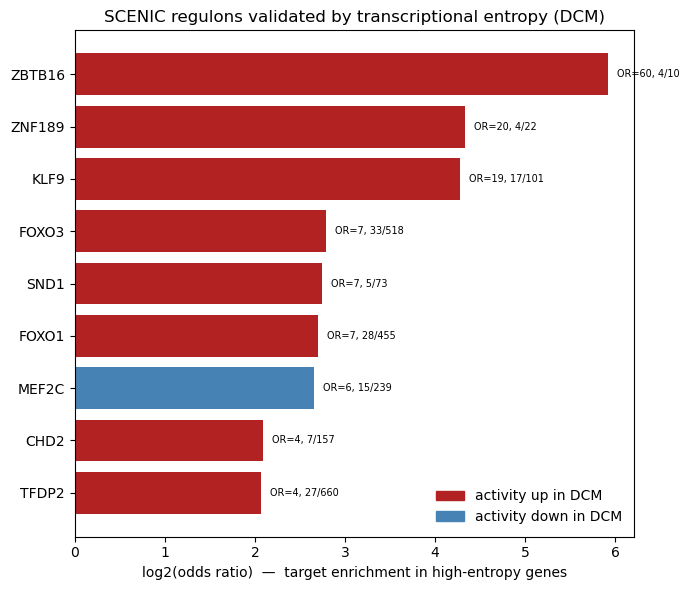

In [59]:
import matplotlib.pyplot as plt
import numpy as np

v = val[val["padj"] < 0.05].copy().sort_values("odds_ratio")
v["neglog10"] = -np.log10(v["padj"])
colors = np.where(v["logFC"] > 0, "firebrick", "steelblue")

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(v["regulon"], np.log2(v["odds_ratio"]), color=colors)
for y,(_,r) in enumerate(v.iterrows()):
    ax.text(np.log2(r["odds_ratio"])+0.1, y,
            f"OR={r['odds_ratio']:.0f}, {r['targets_HE']}/{r['n_targets']}",
            va="center", fontsize=7)

ax.set_xlabel("log2(odds ratio)  —  target enrichment in high-entropy genes")
ax.set_title("SCENIC regulons validated by transcriptional entropy (DCM)")
# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="firebrick", label="activity up in DCM"),
                   Patch(color="steelblue", label="activity down in DCM")],
          frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig("regulon_entropy_validation.png", dpi=200)
plt.show()

In [13]:
import pandas as pd, numpy as np
from scipy.stats import mannwhitneyu, false_discovery_control

d = "/rds/general/user/ao225/home/CardiaFinal/Results/Science/Rogue_outputs"
dcm_groups = ["chromatin","sarcomere","splicing","PVneg"]
load = lambda g: pd.read_csv(f"{d}/ds_{g}.csv").set_index("Gene")["ds"]

# ds per gene: mean across DCM groups, and control
dcm_mean = pd.concat([load(g) for g in dcm_groups], axis=1).mean(axis=1)   # ignores NaN
ctrl     = load("control")

# Δds = DCM - control, only genes tested in control AND ≥1 DCM group
delta = (dcm_mean - ctrl).dropna()

# ENSG -> symbol, collapse duplicates
delta.index = delta.index.map(lambda e: ens2sym.get(e))
delta = delta[delta.index.notna()].groupby(level=0).mean()
universe = set(delta.index)
print("genes with Δds:", len(universe))

# one-sided: do a regulon's targets have HIGHER Δds (more DCM-specific disorder) than the rest?
sig_regs = out.loc[out["padj"] < 0.05, "regulon"].tolist()
rows = []
for tf in sig_regs:
    targ = regulons.get(tf, set()) & universe
    if len(targ) < 5: continue
    inn = delta[delta.index.isin(targ)]
    bg  = delta[~delta.index.isin(targ)]
    U, p = mannwhitneyu(inn, bg, alternative="greater")
    rows.append({"regulon": tf, "n_targets": len(targ),
                 "median_Δds_target": round(inn.median(), 4),
                 "median_Δds_bg": round(bg.median(), 4), "U": U, "pval": p})
r = pd.DataFrame(rows)
r["padj"] = false_discovery_control(r["pval"])
r = r.merge(out[["regulon","logFC"]], on="regulon").sort_values("pval")
print(r.to_string(index=False))

genes with Δds: 19914
regulon  n_targets  median_Δds_target  median_Δds_bg         U         pval         padj     logFC
   KLF9        101             0.0032           -0.0 1406593.0 9.221140e-13 1.936439e-11  0.033273
   NFIB         27             0.0027           -0.0  428128.0 4.440639e-08 3.406784e-07  0.015473
  MEF2C        239             0.0009           -0.0 2821206.0 5.163926e-08 3.406784e-07 -0.011703
  FOXO1        455             0.0004           -0.0 5066849.0 6.489113e-08 3.406784e-07  0.016735
  FOXO3        518             0.0003           -0.0 5617718.0 2.099566e-06 8.818178e-06  0.016625
 ZNF189         22             0.0009           -0.0  323454.0 5.161347e-05 1.806471e-04  0.053170
   CHD2        157             0.0005           -0.0 1771934.0 1.033786e-03 3.101359e-03  0.014119
 ZBTB16         10             0.0085           -0.0  139626.0 1.366912e-02 3.588145e-02  0.104080
   PBX3         70             0.0001           -0.0  786881.0 2.722619e-02 6.352777e-0

In [14]:
import pandas as pd, numpy as np
from scipy.stats import fisher_exact, mannwhitneyu, false_discovery_control

gene_set = "/rds/general/user/ao225/home/CardiaFinal/Results/Science/Rogue_outputs/gene_set"
rogue    = "/rds/general/user/ao225/home/CardiaFinal/Results/Science/Rogue_outputs"
dcm_groups = ["chromatin","sarcomere","splicing","PVneg"]
sig_regs   = out.loc[out["padj"] < 0.05, "regulon"].tolist()

# universe = SE_fun-tested genes (refset), as symbols
universe = {ens2sym.get(e) for e in pd.read_csv(f"{gene_set}/refset.txt", header=None)[0].astype(str)} - {None}
N = len(universe)

# high-entropy symbol sets per group (reload to be safe)
he = {}
for g in dcm_groups + ["control"]:
    ens = pd.read_csv(f"{gene_set}/ds_{g}.txt", header=None)[0].astype(str)
    he[g] = ({ens2sym.get(e) for e in ens} - {None}) & universe

# continuous ds per group
load = lambda g: pd.read_csv(f"{rogue}/ds_{g}.csv").set_index("Gene")["ds"]
ctrl_ds = load("control")

fisher_rows, dds_rows = [], []
for g in dcm_groups:
    # ---- (a) Fisher: group high-entropy (vs control) ----
    hs = he[g] - he["control"]; K = len(hs)
    for tf in sig_regs:
        targ = regulons.get(tf, set()) & universe
        if len(targ) < 5: continue
        a = len(targ & hs); b = len(targ)-a; c = K-a; d = N-len(targ)-c
        odds, p = fisher_exact([[a,b],[c,d]], alternative="greater")
        fisher_rows.append({"regulon":tf,"group":g,"OR":round(odds,1),"pval":p})

    # ---- (b) Δds: this genotype minus control ----
    delta = (load(g) - ctrl_ds).dropna()
    delta.index = delta.index.map(lambda e: ens2sym.get(e))
    delta = delta[delta.index.notna()].groupby(level=0).mean()
    uni = set(delta.index)
    for tf in sig_regs:
        targ = regulons.get(tf, set()) & uni
        if len(targ) < 5: continue
        inn = delta[delta.index.isin(targ)]; bg = delta[~delta.index.isin(targ)]
        U, p = mannwhitneyu(inn, bg, alternative="greater")
        dds_rows.append({"regulon":tf,"group":g,"med_dds":round(inn.median(),4),"pval":p})

fis = pd.DataFrame(fisher_rows); fis["padj"] = fis.groupby("group")["pval"].transform(false_discovery_control)
dds = pd.DataFrame(dds_rows);   dds["padj"] = dds.groupby("group")["pval"].transform(false_discovery_control)

# ---- consensus matrix: regulon validated (BOTH tests padj<0.05) in each genotype ----
pass_f = {(r.regulon, r.group) for r in fis.itertuples() if r.padj < 0.05}
pass_d = {(r.regulon, r.group) for r in dds.itertuples() if r.padj < 0.05}
both = pass_f & pass_d

mat = pd.DataFrame(0, index=sorted({tf for tf,_ in both}), columns=dcm_groups)
for tf, g in both: mat.loc[tf, g] = 1
mat["n_genotypes"] = mat[dcm_groups].sum(axis=1)
print(mat.sort_values("n_genotypes", ascending=False).to_string())

        chromatin  sarcomere  splicing  PVneg  n_genotypes
KLF9            1          1         1      1            4
FOXO1           1          0         1      1            3
FOXO3           1          0         1      1            3
MEF2C           1          1         0      1            3
ZNF189          1          1         0      1            3
CHD2            1          0         0      0            1
NFIB            1          0         0      0            1
TFDP2           0          0         0      1            1
ZBTB16          1          0         0      0            1


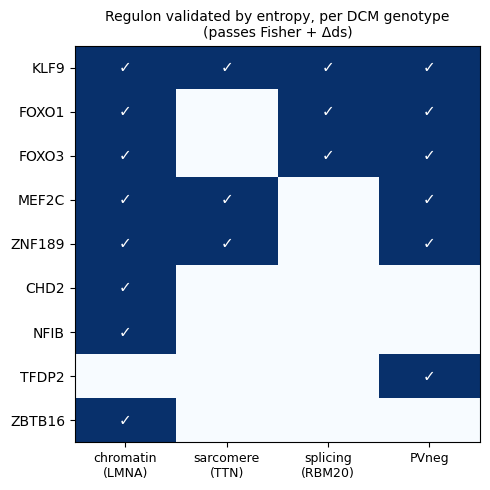

In [62]:
import matplotlib.pyplot as plt
import numpy as np

m = mat[dcm_groups].loc[mat.sort_values("n_genotypes", ascending=False).index]
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(m.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(dcm_groups))); ax.set_xticklabels(
    ["chromatin\n(LMNA)","sarcomere\n(TTN)","splicing\n(RBM20)","PVneg"], fontsize=9)
ax.set_yticks(range(len(m))); ax.set_yticklabels(m.index, fontsize=10)
for i in range(len(m)):
    for j in range(len(dcm_groups)):
        if m.values[i, j]:
            ax.text(j, i, "✓", ha="center", va="center", color="white", fontsize=11)
ax.set_title("Regulon validated by entropy, per DCM genotype\n(passes Fisher + Δds)", fontsize=10)
plt.tight_layout(); plt.savefig("regulon_validation_by_genotype.png", dpi=200)
plt.show()

In [63]:
adata.obs.columns

Index(['Sample', 'donor_id', 'Region_x', 'Primary.Genetic.Diagnosis',
       'n_genes', 'n_counts', 'percent_mito', 'percent_ribo',
       'scrublet_score_z', 'scrublet_score_log', 'solo_score', 'cell_states',
       'Assigned', 'self_reported_ethnicity_ontology_term_id',
       'disease_ontology_term_id', 'cell_type_ontology_term_id',
       'sex_ontology_term_id', 'assay_ontology_term_id', 'is_primary_data',
       'tissue_ontology_term_id', 'development_stage_ontology_term_id',
       'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease',
       'sex', 'tissue', 'self_reported_ethnicity', 'development_stage',
       'observation_joinid'],
      dtype='object')

In [7]:
pathway_map = {
    "LMNA":  "chromatin",
    "TTN":   "sarcomere", "TNNC1": "sarcomere", "TNNT2": "sarcomere",
    "RBM20": "splicing",
    "PVneg": "PVneg",
    "control": "control"
}
adata.obs["pathway"] = adata.obs["Primary.Genetic.Diagnosis"].map(pathway_map)

In [8]:
print(adata.obs["pathway"].value_counts())

pathway
control      39667
sarcomere    26537
chromatin    22186
splicing      6798
PVneg         5340
Name: count, dtype: int64


In [70]:
import scanpy as sc, matplotlib.pyplot as plt

auc_df = pd.DataFrame(adata.obsm["AUCell"], columns=adata.uns["regulons"], index=adata.obs_names)
order = ["control","chromatin","sarcomere","splicing","PVneg"]

reg = "KLF9"
adata.obs[reg] = auc_df[reg].values
vmax = auc_df[reg].quantile(0.99)

fig, axs = plt.subplots(1, len(order), figsize=(4*len(order), 4))
for ax, g in zip(axs, order):
    sub = adata[adata.obs["pathway"] == g]          # <- singular
    sc.pl.umap(sub, color=reg, vmin=0, vmax=vmax, ax=ax, show=False,
               frameon=False, title=f"{reg} — {g}  (n={sub.n_obs})")
plt.tight_layout(); plt.savefig(f"umap_{reg}_by_pathway.png", dpi=200); plt.close()

In [18]:
print([r for r in adata.uns["regulons"] if r in ("SRF","GATA4","GATA6","MYOCD","TBX5","NKX2-5")])
print([t for t in regulons if t in ("SRF","GATA4","GATA6")])   # in the 192 motif-file TFs

[]
['GATA4', 'GATA6']
